In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.graph_objects as go
from ipywidgets import *
import ipympl

In [28]:
def visualize_trajectories(trajectories, as_list=False, alpha=0.1, title="", axis_range=(-100,100)):
    # trajectories should be a numpy array of shape [n_trajs, 3, n_steps]
    # if as_list, trajectories should be an array of len(n_trajs) of numpy array of shape [3, n_steps]
    n_trajs = len(trajectories)
    for i in range(n_trajs):
        if as_list:
            x = trajectories[i][1, :]
            y = trajectories[i][2, :]
        else:
            x = trajectories[i, 1, :]
            y = trajectories[i, 2, :] 
        # alpha_norm_factor = 1 if normalize is False else 2 * np.pi * x
        plt.plot(x, y, alpha=alpha)
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.xlim(axis_range[0], axis_range[1])
    plt.ylim(axis_range[0], axis_range[1])
    plt.show()
    
def visualize_trajectories_3d_mpl(trajectories, as_list=False, alpha=0.1, title="", axis_range=(-100,100)):
    # trajectories should be a numpy array of shape [n_trajs, 3, n_steps]
    # if as_list, trajectories should be an array of len(n_trajs) of numpy array of shape [3, n_steps]
    # mpl.rcParams['axes3d.mouserotationstyle'] = 'trackball'  # 'azel', 'trackball', 'sphere', or 'arcball'
    ax = plt.figure().add_subplot(projection='3d')
    n_trajs = len(trajectories)
    for i in range(n_trajs):
        if as_list:
            x = trajectories[i][0, :]
            y = trajectories[i][1, :]
            z = trajectories[i][2, :]
        else:
            x = trajectories[i, 0, :]
            y = trajectories[i, 1, :] 
            z = trajectories[i, 2, :] 
        # alpha_norm_factor = 1 if normalize is False else 2 * np.pi * x
        plt.plot(x, y, z, alpha=alpha)
    # ax.set_aspect('equal', adjustable='box')
    plt.title(title)
    ax.set_xlim(axis_range[0], axis_range[1])
    ax.set_ylim(axis_range[0], axis_range[1])
    ax.set_zlim(axis_range[0], axis_range[1])
    plt.show()
    
    
def visualize_trajectories_3d_plotly(trajectories, as_list=False, alpha=0.1, title="", axis_range=(-100,100)):
    # trajectories should be a numpy array of shape [n_trajs, 3, n_steps]
    # if as_list, trajectories should be an array of len(n_trajs) of numpy array of shape [3, n_steps]
    def get_circle(r, z):
        x = np.cos(np.linspace(0, 2*np.pi, 100)) * r
        y = np.sin(np.linspace(0, 2*np.pi, 100)) * r
        z = np.ones(shape=100) * z
        return x,y,z
    
    fig = go.Figure()
    circles = [(54, 15), (54, -15), (39, 0)]
    for (r,z) in circles:
        x,y,z = get_circle(r,z)
        fig.add_trace(
            go.Scatter3d(
                x=x, y=y, z=z,
                mode='lines',
                opacity=0.5,
                line=dict(width=2, color="black"),
                showlegend=False
            )
        )
    
    n_trajs = len(trajectories)
    for i in range(n_trajs):
        if as_list:
            x = trajectories[i][0, :]
            y = trajectories[i][1, :]
            z = trajectories[i][2, :]
        else:
            x = trajectories[i, 0, :]
            y = trajectories[i, 1, :]
            z = trajectories[i, 2, :]
        # Add each trajectory as a 3D line
        fig.add_trace(
            go.Scatter3d(
                x=x, y=y, z=z,
                mode='lines',
                opacity=alpha,
                line=dict(width=2),
                showlegend=False
            )
        )
    # Update layout for equal aspect ratio and axis ranges
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(range=[axis_range[0], axis_range[1]]),
            yaxis=dict(range=[axis_range[0], axis_range[1]]),
            zaxis=dict(range=[axis_range[0], axis_range[1]]),
            aspectmode='cube'  # This ensures equal aspect ratio
        ),
        width=800,
        height=800
    )
    fig.show()
    return fig
    
def calc_limited_trajectories(trajectories, min_val, max_val, axis):
    # creates a list only of subtrajectories that are within range in the axis
    new_trajs = []
    n_trajs, _, n_steps = trajectories.shape
    for i in range(n_trajs):
        traj = []
        for j in range(n_steps):
            coords = trajectories[i, :, j]
            if coords[axis] < min_val or coords[axis] > max_val:
                if traj != []:
                    new_trajs.append(np.vstack(traj).T)
                    traj = []
                continue
            traj.append(coords)
        if traj != []:
            new_trajs.append(np.vstack(traj).T)
    return new_trajs
    
def calc_radial_dist_trajectories(trajectories):
    new_trajs = np.zeros_like(trajectories)
    n_trajs, _, n_steps = trajectories.shape
    new_trajs[:, 2, :] = trajectories[:, 2, :]
    new_trajs[:, 1, :] = np.sqrt(trajectories[:, 0, :] ** 2 + trajectories[:, 1, :] ** 2)
    return new_trajs
    

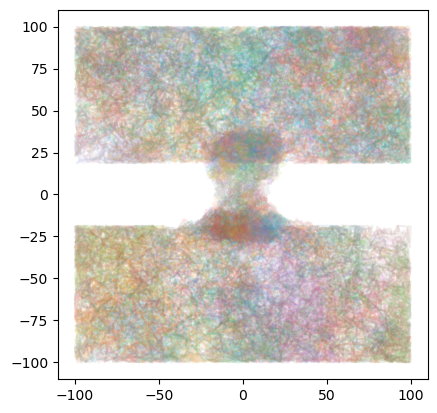

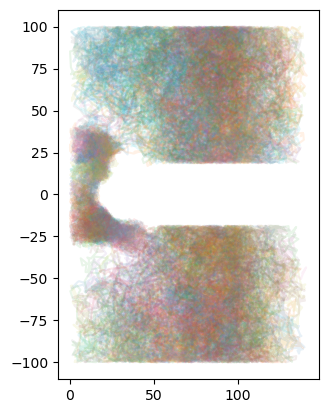

In [23]:
with open("data/spatial_markov_chain_data.pickle", "rb") as f:
    trajectories = pickle.load(f)
visualize_trajectories(trajectories)
# new_trajs = calc_limited_trajectories(trajectories, 40, 50, 0)
# visualizse_trajectories(new_trajs)
new_trajs = calc_radial_dist_trajectories(trajectories)
visualize_trajectories(new_trajs, as_list=False)

In [29]:
%matplotlib widget

arrays = []
for i in range(1, 9):
    with open(f"data/singles/{i}/110-130.pickle", "rb") as f:
        arrays.append(pickle.load(f))
for i in range(17, 50):
    with open(f"data/singles/{i}/110-130.pickle", "rb") as f:
        arrays.append(pickle.load(f))
trajectories = np.concatenate(arrays, axis=0)
rng = np.random.default_rng()
sample_trajs = rng.choice(trajectories, size=50, replace=False, axis=0, shuffle=True)

passed = [3834,5385,7087,7426,8632,9403,9590,9791]

fig = visualize_trajectories_3d_plotly(trajectories[passed], alpha=0.5, title="50 random paths", axis_range=[-50, 50])
fig.write_html("trajectories.html")
# visualize_trajectories(sample_trajs, alpha=0.5, title="50 random paths", axis_range=[-50, 50])
# visualize_trajectories(trajectories, alpha=0.1)
# new_trajs = calc_radial_dist_trajectories(trajectories)
# visualize_trajectories(new_trajs, as_list=False, alpha=0.1, title="By radial distance (not normalized)")


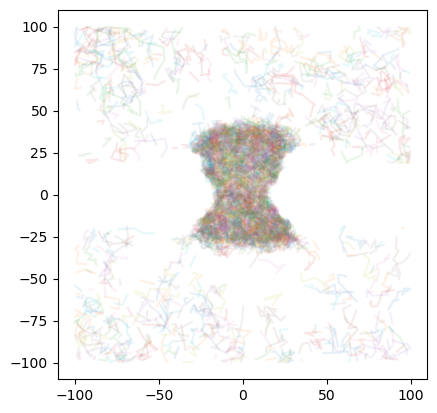

In [39]:
new_trajs = calc_limited_trajectories(trajectories, -5, 5, 0)
visualize_trajectories(new_trajs, as_list=True, alpha=0.1)
# print(np.vstack(new_trajs).shape)